# Stock Price Predictor

This program build a regression model to predict NVIDIA's stock price the next day using historical stock market data. 

Two data sets are used, historical data from the last one, three, and five years. In order to see which length is the best predictor for tomorrow's price.

Dataset Source: StockQuote 

Models: Linear Regression, Random Forest

# Reading Data

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv('NVDA_data1.csv')
df3 = pd.read_csv('NVDA_data3.csv')
df5 = pd.read_csv('NVDA_data5.csv')
dataframes = [df1, df3, df5]
df1.head()

,DATE,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME
0,"Mar 27, 2026",169.99,170.97,167.01,167.52,167.52,194056113
1,"Mar 26, 2026",176.07,176.51,171.14,171.24,171.24,186152200
2,"Mar 25, 2026",177.10,181.22,176.85,178.68,178.68,162602100
3,"Mar 24, 2026",174.83,176.22,173.98,175.20,175.20,147667800
4,"Mar 23, 2026",177.26,178.37,174.76,175.64,175.64,182836300


Note the dates are sorted earliest to oldest. In order to see the change over time we must reverse the Dataframe. 

In [48]:
df1 = df1.iloc[::-1].reset_index(drop=True)
df3 = df3.iloc[::-1].reset_index(drop=True)
df5 = df5.iloc[::-1].reset_index(drop=True)
df1.head()

,DATE,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME
0,"Mar 28, 2025",111.49,112.87,109.07,109.67,109.64,229872500
1,"Mar 31, 2025",105.13,110.96,103.65,108.38,108.35,299212700
2,"Apr 01, 2025",108.52,110.20,106.47,110.15,110.12,222614000
3,"Apr 02, 2025",107.29,111.98,106.79,110.42,110.39,220601200
4,"Apr 03, 2025",103.51,105.63,101.60,101.80,101.78,338769400


In [49]:
df1.describe()

,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,167.129801,169.442072,164.576494,167.094422,167.074223,1.971558e+08
std,27.641169,27.487263,27.333769,27.147471,27.151870,7.265844e+07
min,87.460000,99.440000,86.620000,94.310000,94.290000,6.552850e+07
25%,156.010000,157.400000,153.485000,156.135000,156.105000,1.540318e+08
50%,178.170000,180.900000,175.790000,178.260000,178.230000,1.798022e+08
75%,184.850000,187.410000,182.200000,184.955000,184.945000,2.212502e+08
max,208.080000,212.190000,205.560000,207.040000,207.020000,6.129183e+08


In [50]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   DATE       251 non-null    object 
 1   OPEN       251 non-null    float64
 2   HIGH       251 non-null    float64
 3   LOW        251 non-null    float64
 4   CLOSE      251 non-null    float64
 5   ADJ CLOSE  251 non-null    float64
 6   VOLUME     251 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 13.9+ KB


In [51]:
#Dropping Adj Close due to similarites with Close
for df in dataframes:
    df.drop(['ADJ CLOSE'], axis=1, inplace=True)

# Exploratory Data Analysis

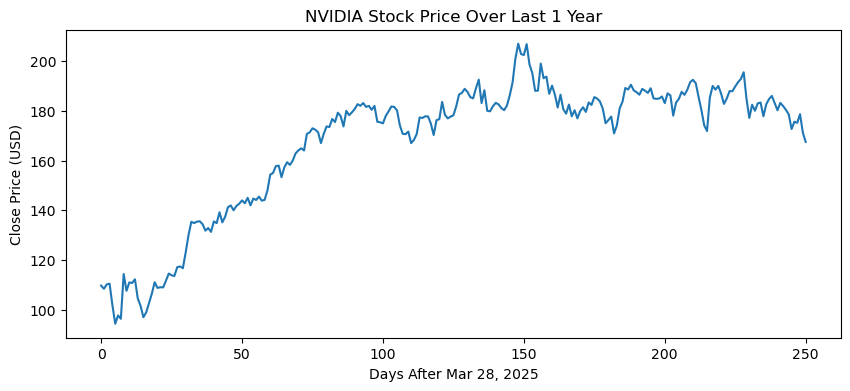

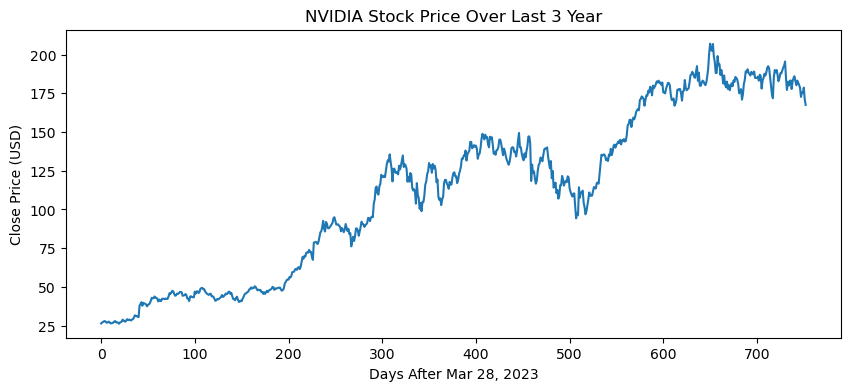

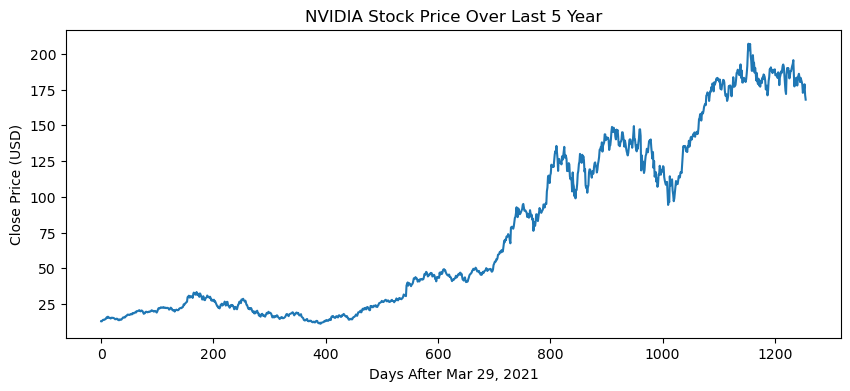

In [52]:
def close_price(df, title):
    #Line graph for closing price over time
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(df['CLOSE'])
    ax.set_title(title)
    ax.set_xlabel(f'Days After {df['DATE'][0]}')
    ax.set_ylabel('Close Price (USD)')
    plt.show()

close_price(df1, "NVIDIA Stock Price Over Last 1 Year")
close_price(df3, "NVIDIA Stock Price Over Last 3 Year")
close_price(df5, "NVIDIA Stock Price Over Last 5 Year")


We can see in every graph that NVIDIA's stock price has greatly increased over time. I am most intrigued by the three years period, as it seems the stock could almost be split into three separate plateaus.

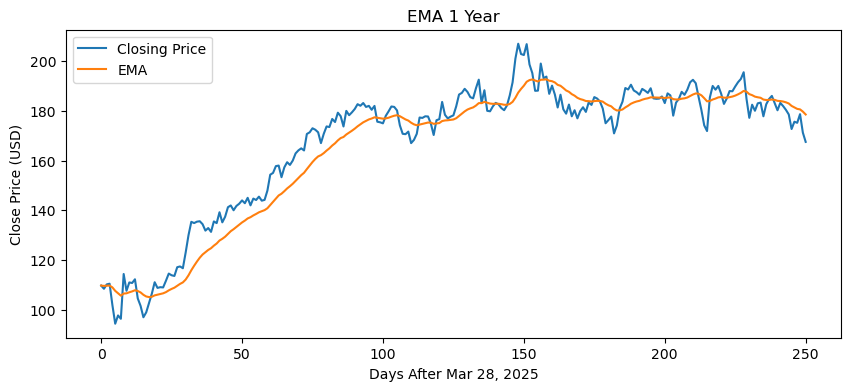

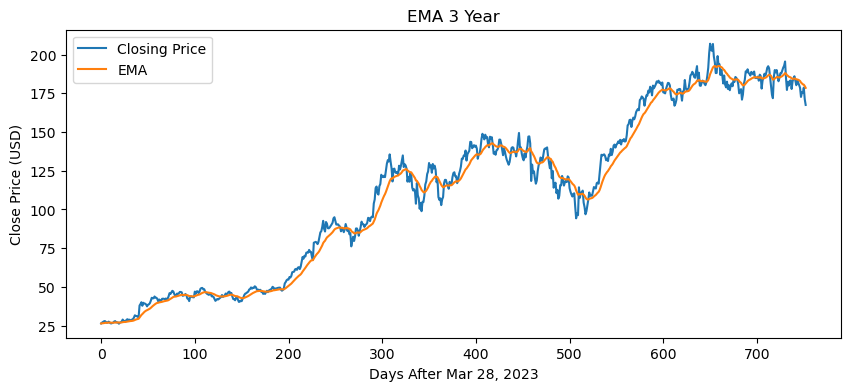

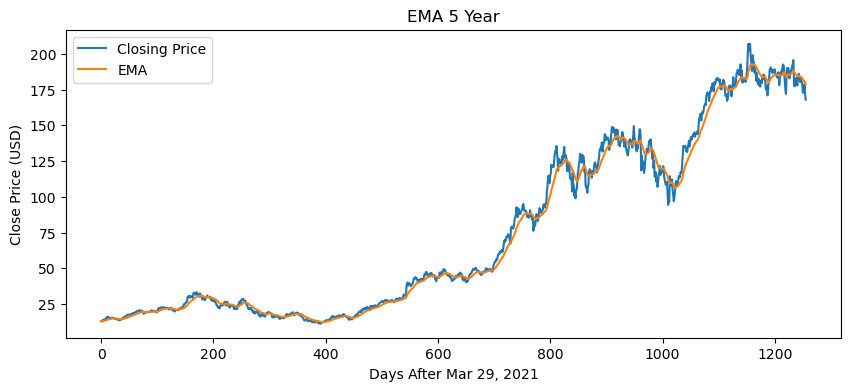

In [53]:
def ema(df, title):
    #Finding the Exponential Moving Average
    ema = df['CLOSE'].ewm(span=20,adjust=False).mean()
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(df['CLOSE'], label="Closing Price")
    ax.plot(ema, label="EMA")
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel(f'Days After {df['DATE'][0]}')
    ax.set_ylabel('Close Price (USD)')
    plt.show()

ema(df1, "EMA 1 Year")
ema(df3, "EMA 3 Year")
ema(df5, "EMA 5 Year")

In [54]:
#Splitting date column into day, month, and year
def time_split(df):
    temp_date = pd.to_datetime(df['DATE'])
    df['DAY'] = temp_date.dt.day
    df['MONTH'] = temp_date.dt.month
    df['YEAR'] = temp_date.dt.year
    return df

df1 = time_split(df1)
df3 = time_split(df3)
df5 = time_split(df5)
df5.head()

,DATE,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME,DAY,MONTH,YEAR
0,"Mar 29, 2021",12.82,13.06,12.70,12.95,12.92,273520000,29,3,2021
1,"Mar 30, 2021",12.84,12.98,12.70,12.87,12.84,200204000,30,3,2021
2,"Mar 31, 2021",13.02,13.47,12.98,13.35,13.31,314776000,31,3,2021
3,"Apr 01, 2021",13.57,13.87,13.51,13.81,13.78,308276000,1,4,2021
4,"Apr 05, 2021",13.87,14.01,13.73,13.99,13.95,255672000,5,4,2021


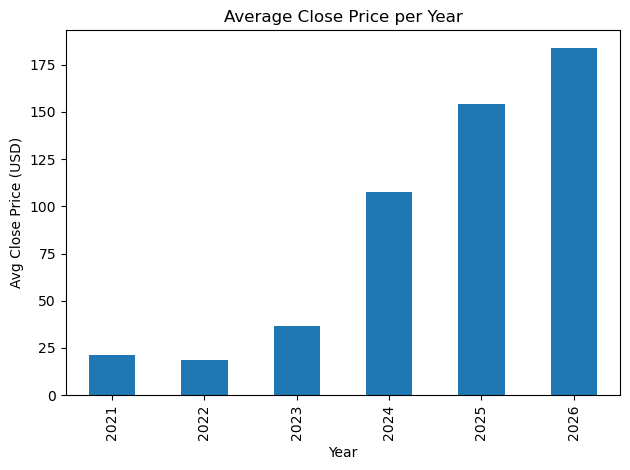

In [55]:
yearly_avg = df5.groupby('YEAR')['CLOSE'].mean()
yearly_avg.plot.bar()
plt.title("Average Close Price per Year")
plt.xlabel('Year')
plt.ylabel('Avg Close Price (USD)')
plt.tight_layout()
plt.show()

# Feature Engineering

In [56]:
def features_engineering(df):
    df = df.copy()
    # The model will try to predict tomorrow's close price
    df['target'] = df['CLOSE'].shift(-1)

    #Difference in daily features
    df['open_close_diff'] = df['OPEN'] - df['CLOSE']
    df['low_high_diff'] = df['LOW'] - df['HIGH']

    # Moving Averages
    df['MA_5'] = df['CLOSE'].rolling(5).mean()
    df['MA_10'] = df['CLOSE'].rolling(10).mean()
    df['MA_20'] = df['CLOSE'].rolling(20).mean()

    # Volatility 
    df['volatility'] = df['CLOSE'].pct_change().rolling(10).std()

    #Drop Na from rolling calculations
    df.dropna(inplace=True)

    return df
    
df1_features = features_engineering(df1)
df3_features = features_engineering(df3)
df5_features = features_engineering(df5)
df1_features.head()

,DATE,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME,DAY,MONTH,YEAR,target,open_close_diff,low_high_diff,MA_5,MA_10,MA_20,volatility
19,"Apr 25, 2025",106.85,111.92,105.73,111.01,110.98,251064700,25,4,2025,108.73,-4.16,-6.19,103.190,105.577,105.3170,0.038971
20,"Apr 28, 2025",109.69,110.37,106.02,108.73,108.70,207708500,28,4,2025,109.02,0.96,-4.35,105.554,105.357,105.2700,0.038363
21,"Apr 29, 2025",107.67,110.20,107.44,109.02,108.99,170444300,29,4,2025,108.92,-1.35,-2.76,107.580,105.188,105.3020,0.038382
22,"Apr 30, 2025",104.47,108.92,104.08,108.92,108.89,235044600,30,4,2025,111.61,-4.45,-4.84,108.822,104.860,105.2405,0.038054
23,"May 01, 2025",113.08,114.94,111.30,111.61,111.58,236121500,1,5,2025,114.50,1.47,-3.64,109.858,105.572,105.3000,0.030693


<Axes: >

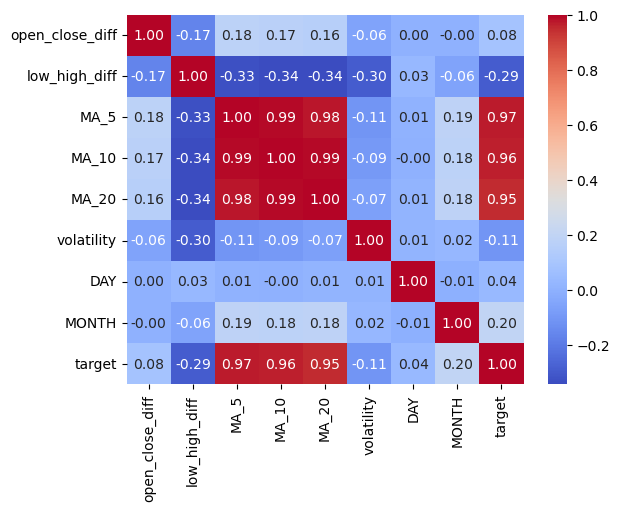

In [57]:
features =  ['open_close_diff', 'low_high_diff', 'MA_5', 'MA_10', 'MA_20', 'volatility', 'DAY', 'MONTH']
correlation = df1_features[features+['target']].corr()
sns.heatmap(correlation, cmap='coolwarm', fmt='.2f', annot=True)


# Model Evaluation


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from math import sqrt

def training(df, features):
  #Training & Testing model with 70/30 split with scaling
  X=df[features].values
  y=df['target'].values
  xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3,shuffle=False)
  scaler = StandardScaler()
  xtrain = scaler.fit_transform(xtrain)

  return xtrain, xtest, ytrain, ytest, scaler

def evaluate(df, features, title):
  xtrain, xtest, ytrain, ytest, scaler = training(df, features)
  models = {'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor()}
  
  best_model = 'Na'
  best_score = float('inf')
  print(title)
  for name, model in models.items():
    model.fit(xtrain,ytrain)
    pred = model.predict(xtest)
    
    mea = mean_absolute_error(ytest, pred)
    r2 = r2_score(ytest, pred)
    if mea < best_score:
      best_score = mea
      best_model = model
    print(f"{name}")
    print(f"Mean Absolute Error: : {mea}")
    print(f"RMSE: {sqrt(mean_squared_error(ytest,pred))}")
    print(f"R2 Score: : {r2}")
    print()

  print(f"The best model is {best_model} with {best_score}")
  print()
  return best_model, df, scaler
  

In [59]:
model1, feature1, scaler1 = evaluate(df1_features, features, "--Year 1 Regression--")
model3, feature3, scaler3 = evaluate(df3_features, features, "--Year 3 Regression--")
model5, feature5, scaler5 = evaluate(df5_features, features, "--Year 5 Regression--")

--Year 1 Regression--
Linear Regression
Mean Absolute Error: : 4008.359506261259
RMSE: 4009.549440109016
R2 Score: : -467423.11676651915

Random Forest
Mean Absolute Error: : 17.85031714285707
RMSE: 18.750616339454712
R2 Score: : -9.22235750960962

The best model is RandomForestRegressor() with 17.85031714285707

--Year 3 Regression--
Linear Regression
Mean Absolute Error: : 6597.49037521356
RMSE: 6629.889888869538
R2 Score: : -158582.15601636202

Random Forest
Mean Absolute Error: : 39.06462454545449
RMSE: 42.2096497224767
R2 Score: : -5.427882388274185

The best model is RandomForestRegressor() with 39.06462454545449

--Year 5 Regression--
Linear Regression
Mean Absolute Error: : 5049.533811119277
RMSE: 5129.50701584879
R2 Score: : -33572.457721720755

Random Forest
Mean Absolute Error: : 39.506361455525614
RMSE: 46.68560334191386
R2 Score: : -1.781062612929416

The best model is RandomForestRegressor() with 39.506361455525614



We can see the model with the lowest Mean Error is Random Forest trained on the first year dataset. 

# Predicting Closing Price

With the data available, we can use the best model to predict the closing price for tomorrow. We will use the 1 year model because it seems that shorter windows are more accurate at predicting recent market trends.

In [60]:
# Predict the next day's close price using the best model from the 1 year data
def predict(df, model, scaler, features):
    last = df[features].iloc[[-1]]
    last = scaler.transform(last)
    pred = model.predict(last)[0]
    return pred

last_date = df1_features['DATE'].iloc[-1]
next_price = predict(feature1, model1, scaler1, features)
last_close = df1['CLOSE'].iloc[-1]
print(f"Last Close Price on {last_date}: ${last_close:.2f}")
print(f"Predicted Close Price for Next Day: ${next_price:.2f}")

Last Close Price on Mar 26, 2026: $167.52
Predicted Close Price for Next Day: $173.76


c:\Users\james\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


# Conclusion

We can see the predictions across the three different year models offer insights into the volatilaty of NVIDIA's stock price. The regression metrics (MAE) evaluate the model's performance and give insight into its accuracy.

* The Moving Averages showed to be the best predicting feature of the dataset. 
* The one-year model performed the best because it was only trained on the recent market. 
* This program was only built for learning purposes and will not be used as indication whether to buy stocks. 
* This dataset does not look into how news and real-life factors could affect the stock market.